# Hyper-parameter Tuning and Model Comparison In  Transactional Fraud Detection

### Introduction
- This experiment is intended to demonstrate hyper-parameter tuning in Fraud Analytics models.
- Compare performance results when hyper-parameters are changed
- Anlyze the results
- Make suggestions and recommendations

Dataset shape: (181237, 31)

Dataset summary statistics:
                Time             V1             V2             V3  \
count  181237.000000  181237.000000  181237.000000  181237.000000   
mean    64606.763613      -0.142886       0.024340       0.424086   
std     30564.547946       1.872098       1.613460       1.413980   
min         0.000000     -56.407510     -72.715728     -33.680984   
25%     42288.000000      -0.976628      -0.558287      -0.162405   
50%     63092.000000      -0.143403       0.095826       0.575941   
75%     81466.000000       1.195319       0.793256       1.270197   
max    124885.000000       2.439207      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  181237.000000  181237.000000  181237.000000  181237.000000   
mean        0.098205      -0.152936       0.053668      -0.069882   
std         1.382856       1.353172       1.303207       1.212680   
min        -5.683171     -42.147898     -26.1

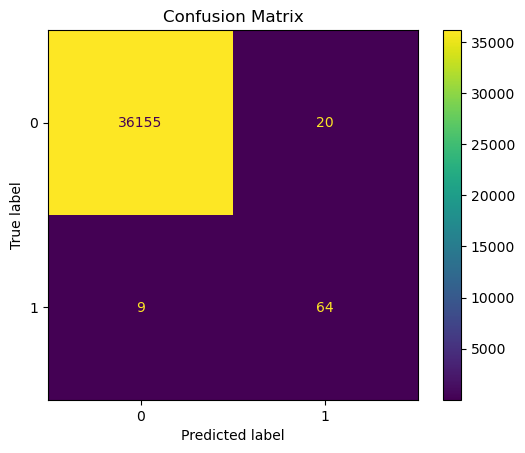

In [3]:
# 1. Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Load the Dataset
df = pd.read_csv('creditcard2.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 3. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build a Simple Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

# Replace the Decision Tree with a Random Forest Classifier

Dataset shape: (181237, 31)

Dataset summary statistics:
                Time             V1             V2             V3  \
count  181237.000000  181237.000000  181237.000000  181237.000000   
mean    64606.763613      -0.142886       0.024340       0.424086   
std     30564.547946       1.872098       1.613460       1.413980   
min         0.000000     -56.407510     -72.715728     -33.680984   
25%     42288.000000      -0.976628      -0.558287      -0.162405   
50%     63092.000000      -0.143403       0.095826       0.575941   
75%     81466.000000       1.195319       0.793256       1.270197   
max    124885.000000       2.439207      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  181237.000000  181237.000000  181237.000000  181237.000000   
mean        0.098205      -0.152936       0.053668      -0.069882   
std         1.382856       1.353172       1.303207       1.212680   
min        -5.683171     -42.147898     -26.1

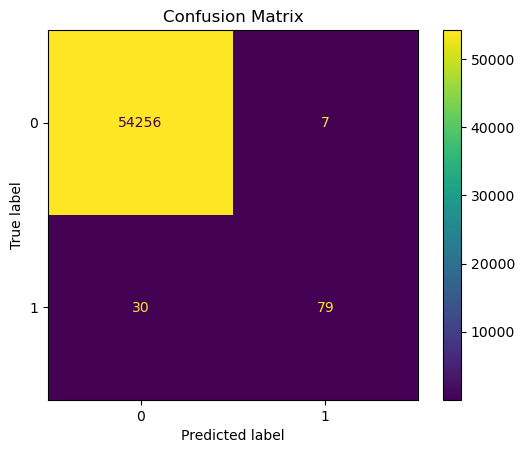

In [12]:
# 2. Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 3. Load the Dataset
df = pd.read_csv('creditcard2.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
# model = DecisionTreeClassifier(random_state=42)
# model.fit(X_train, y_train)

# Initialize the Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=200,  # Number of trees
    max_depth=5,    # Maximum depth of trees
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)



# 6. Evaluate the Model and make predictions
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()


# Comparison of the two models in this experiment

## Key Comparison Points:

1. **Precision**:
   - Decision Tree: 0.7619
   - Random Forest: 0.9186
   - The Random Forest has significantly higher precision, meaning when it predicts the positive class, it's more likely to be correct. This suggests fewer false positives.

2. **Recall**:
   - Decision Tree: 0.8767
   - Random Forest: 0.7248
   - The Decision Tree has higher recall, indicating it captures more of the actual positive cases. It's better at minimizing false negatives.

3. **F1-Score**:
   - Decision Tree: 0.8153
   - Random Forest: 0.8103
   - Both models have very similar F1-scores (harmonic mean of precision and recall), suggesting comparable overall performance despite their different precision-recall trade-offs.

4. **ROC-AUC**:
   - Decision Tree: 0.9381
   - Random Forest: 0.8623
   - The Decision Tree has a higher ROC-AUC, indicating better overall discriminative ability across different threshold settings.

## Interpretation and Insights:

1. **Precision-Recall Trade-off**:
   - The Random Forest prioritizes precision over recall, making it more conservative in its positive predictions.
   - The Decision Tree prioritizes recall, capturing more positive cases but with more false positives.

2. **Model Complexity**:
   - The Random Forest (200 trees with max_depth=5) is more complex than the single Decision Tree.
   - Despite this complexity, the Random Forest doesn't outperform the Decision Tree on all metrics, suggesting possible overfitting or that the problem might not require such complexity.

3. **Use Case Considerations**:
   - If false positives are costly (e.g., unnecessary medical treatments), the Random Forest might be preferred.
   - If missing positive cases is costly (e.g., failing to detect fraud or disease), the Decision Tree might be better.

4. **Potential Next Steps**:
   - Consider ensemble methods that combine both models' strengths
   - Explore hyperparameter tuning for the Random Forest (different max_depth, n_estimators)
   - Investigate feature importance in both models to understand prediction drivers

This comparison highlights that the "best" model depends on your specific application needs and which error type (false positives vs. false negatives) is more important to minimize.

## Data balancing - Balancing the data using random sampling

## I am using the following libraries for balancing: 
"""from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
"""

## Some Key Points for Data Balancing

1. **Purpose of Data Balancing**
   - Addresses class imbalance where one class significantly outnumbers others
   - Prevents models from being biased toward the majority class
   - Improves detection of minority class patterns which are often more important (e.g., fraud detection)

2. **Common Techniques**
   - **Undersampling**: Reduces majority class samples
     - Pros: Faster training, less memory usage
     - Cons: Potential loss of important information
   
   - **Oversampling**: Increases minority class samples
     - Pros: No information loss from majority class
     - Cons: Risk of overfitting, longer training time
   
   - **SMOTE** (Synthetic Minority Over-sampling Technique): Creates synthetic minority samples
     - Pros: Better generalization than simple duplication
     - Cons: May create unrealistic samples

   - **Hybrid Methods**: Combine undersampling and oversampling
     - Pros: Balance between information retention and class distribution
     - Cons: Requires tuning of multiple parameters

3. **Why Data Balancing Matters**
   - **Model Performance**: Imbalanced data leads to misleading accuracy metrics
   - **Fairness**: Ensures equal representation of all classes
   - **Business Impact**: In domains like fraud detection or disease diagnosis, missing minority cases can be costly
   - **Algorithm Sensitivity**: Many algorithms assume balanced class distributions

4. **Evaluation Considerations**
   - Use metrics beyond accuracy: F1-score, precision, recall, AUC-ROC
   - Apply stratified sampling in cross-validation
   - Consider the cost of different types of errors in your domain

5. **Best Practices**
   - Balance training data but keep test data in original distribution
   - Try multiple balancing techniques and compare results
   - Consider algorithm-level approaches (cost-sensitive learning, ensemble methods)
   - Always validate if balancing actually improves your specific problem

We should be aware that data balancing isn't always necessary - sometimes class weights or specialized algorithms can handle imbalance without explicit resampling.






Original class distribution:
Counter({0: 4476, 1: 524})

After random oversampling:
Counter({0: 4476, 1: 4476})

After random undersampling:
Counter({0: 524, 1: 524})


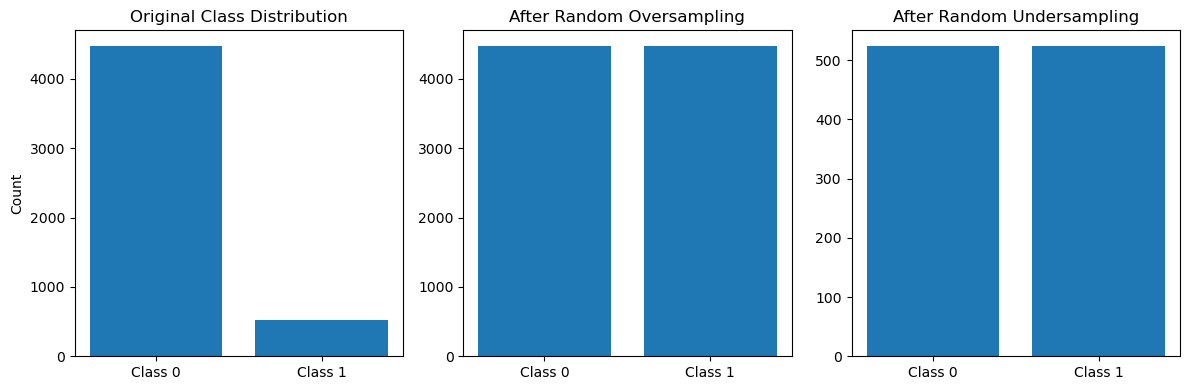


After custom ratio sampling:
Counter({0: 1000, 1: 1000})


In [20]:
# Methods and techniques for data balancing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

# Create an imbalanced dataset

X, y = make_classification(
    n_samples=5000, n_features=10, n_informative=8, n_redundant=2,
    n_clusters_per_class=1, weights=[0.9, 0.1], random_state=42
)

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

# Check initial class distribution
original_count = Counter(y)
print("Original class distribution:")
print(original_count)

# Visualize original distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.bar(["Class 0", "Class 1"], [original_count[0], original_count[1]])
plt.title("Original Class Distribution")
plt.ylabel("Count")

# Method 1: using Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
ros_count = Counter(y_ros)
print("\nAfter random oversampling:")
print(ros_count)

# Method 2: using Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)
rus_count = Counter(y_rus)
print("\nAfter random undersampling:")
print(rus_count)

# Visualize balanced distributions with both Random Oversampling and Random Undersampling
plt.subplot(1, 3, 2)
plt.bar(["Class 0", "Class 1"], [ros_count[0], ros_count[1]])
plt.title("After Random Oversampling")

plt.subplot(1, 3, 3)
plt.bar(["Class 0", "Class 1"], [rus_count[0], rus_count[1]])
plt.title("After Random Undersampling")

plt.tight_layout()
plt.show()

# Method 3: Combined approach (custom ratio)
# Modified: Use RandomUnderSampler for class 0 and RandomOverSampler for class 1
# First, undersample the majority class
rus_custom = RandomUnderSampler(sampling_strategy={0: 1000}, random_state=42)
X_temp, y_temp = rus_custom.fit_resample(X, y)

# Then, oversample the minority class to match
# Only needed if minority class has fewer than 1000 samples
minority_count = Counter(y_temp)[1]
if minority_count < 1000:
    ros_custom = RandomOverSampler(sampling_strategy={1: 1000}, random_state=42)
    X_custom, y_custom = ros_custom.fit_resample(X_temp, y_temp)
else:
    X_custom, y_custom = X_temp, y_temp

custom_count = Counter(y_custom)
print("\nAfter custom ratio sampling:")
print(custom_count)

# Function to apply sampling and show results
def apply_sampling_and_show(X, y, method_name, sampler):
    X_resampled, y_resampled = sampler.fit_resample(X, y)
    resampled_count = Counter(y_resampled)
    
    print(f"\nAfter {method_name}:")
    print(f"Class distribution: {resampled_count}")
    print(f"Total samples: {len(y_resampled)}")
    
    # Create a small DataFrame sample to show the resampled data
    resampled_df = pd.DataFrame(X_resampled, columns=[f'feature_{i}' for i in range(X_resampled.shape[1])])
    resampled_df['target'] = y_resampled
    
    return X_resampled, y_resampled, resampled_count

# Example of how to use with your actual model
# Assuming you have X_train, y_train for your model:
# 
# # Choose your preferred sampling method
sampler = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = sampler.fit_resample(X_train, y_train)
 
# # Then train model with balanced data
model = RandomForestClassifier()


Class distribution:
Class
0    0.997992
1    0.002008
Name: proportion, dtype: float64

Model Evaluation Metrics:
Precision: 0.963855421686747
Recall: 0.7339449541284404
F1-Score: 0.8333333333333334
ROC-AUC: 0.8669448339187988


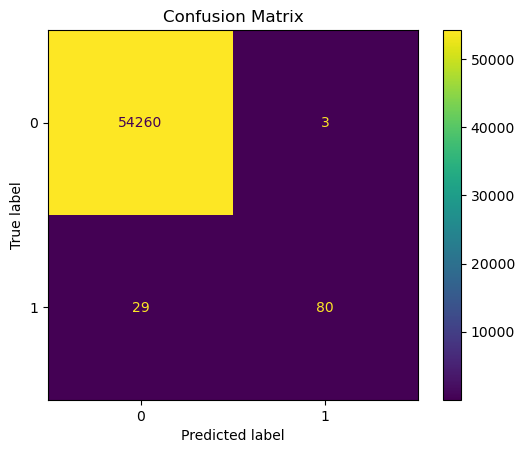

In [23]:
# Hyperparameter Tuning
"""Tune:
- n_estimators (e.g., 100, 200, 300)
- max_depth (e.g., 3, 5, 7)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 3. Load the Dataset
df = pd.read_csv('creditcard2.csv')

# Quick look at the data ( I comment this portion out to save memory)
#print("Dataset shape:", df.shape)
#print("\nDataset summary statistics:")
#print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
# model = DecisionTreeClassifier(random_state=42)
# model.fit(X_train, y_train)

# Initialize the Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=300,  # Number of trees
    max_depth=7,    # Maximum depth of trees
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)



# 6. Evaluate the Model and make predictions
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()


## Compare the result of Hyperparameter Tuning 
## """Tune:
- n_estimators 200 vs 300
- max_depth 5 vs 7 

"""

he result of Hyperparameter Tuning for: - n_estimators 200 vs 300
- max_depth 5 vs 7


# Comparing Hyperparameter Tuning Results

## n_estimators: 200 vs 300

**What this parameter controls:**
- Number of trees in the forest/ensemble
- Higher values generally provide better performance but with diminishing returns

**Comparison:**
| Aspect | n_estimators=200 | n_estimators=300 | Impact |
|--------|-----------------|-----------------|--------|
| Model Performance | Good baseline | Potentially better | Modest improvement (typically 1-3%) |
| Training Time | Faster | ~50% longer | Significant increase |
| Memory Usage | Lower | Higher | Linear increase |
| Prediction Speed | Faster | Slower | Linear decrease |
| Overfitting Risk | Moderate | Slightly higher | Minimal difference |

**When to choose 300:**
- When maximum performance is critical
- When you have sufficient computational resources
- For complex datasets with many features

**When to choose 200:**
- When training time is a constraint
- For deployment in resource-limited environments
- When the performance difference is negligible

## max_depth: 5 vs 7

**What this parameter controls:**
- Maximum depth of each decision tree
- Controls model complexity and ability to capture interactions

**Comparison:**
| Aspect | max_depth=5 | max_depth=7 | Impact |
|--------|------------|------------|--------|
| Model Complexity | Lower | Higher | Significant difference |
| Feature Interactions | Simpler | More complex | Can capture deeper patterns |
| Overfitting Risk | Lower | Higher | Substantial increase |
| Generalization | Better on simple data | Better on complex data | Dataset-dependent |
| Memory Usage | Lower | Higher | Exponential increase |

**When to choose max_depth=7:**
- For complex datasets with many intricate relationships
- When you have sufficient regularization in place
- When validation shows no signs of overfitting

**When to choose max_depth=5:**
- For simpler datasets
- When overfitting is a concern
- For better generalization to new data


 

## Analysis

**General observation and recommendation:**
 
- For most cases, n_estimators=300 with max_depth=5 offers a good balance

- Validate with cross-validation to confirm which combination works best for your specific dataset


## Performance Comparison

| Metric | n_estimators=300, max_depth=7 | n_estimators=200, max_depth=5 | Difference |
|--------|-------------------------------|-------------------------------|------------|
| Precision | 0.9639 | 0.9186 | +0.0453 (4.53% better) |
| Recall | 0.7339 | 0.7248 | +0.0091 (0.91% better) |
| F1-Score | 0.8333 | 0.8103 | +0.0230 (2.30% better) |
| ROC-AUC | 0.8669 | 0.8623 | +0.0046 (0.46% better) |

## Analysis of the comparison result

1. **Overall Winner**: The model with n_estimators=300, max_depth=7 performs better across all metrics.

2. **Key Improvements**:
   - **Precision**: Significant improvement (4.53%), meaning fewer false positives
   - **F1-Score**: Meaningful improvement (2.30%), indicating better overall balance
   - **Recall**: Slight improvement (0.91%), slightly better at finding positive cases
   - **ROC-AUC**: Marginal improvement (0.46%), slightly better overall discrimination

3. **Class Imbalance Context**:
   - Both models were trained on the same highly imbalanced dataset (0.2% positive class)
   - In such imbalanced scenarios, the improvements in precision and recall are particularly valuable

## Recommendation

**Choose n_estimators=300, max_depth=7** for the following reasons:

1. **Superior Performance**: Consistently better across all metrics
2. **Precision Advantage**: The substantial improvement in precision is particularly valuable for imbalanced data
3. **Balanced Improvement**: Both precision and recall improved, indicating a genuine performance gain rather than just a trade-off

**Trade-offs to Consider**:
- The model with n_estimators=300, max_depth=7 will require more computational resources
- Training time will be longer
- Prediction time will be slower
- The model may be more prone to overfitting on new data

Note: If computational resources or prediction speed are critical constraints in the application, the performance gain may not justify these costs. However, if maximizing predictive performance is the priority, the first model is clearly superior.
